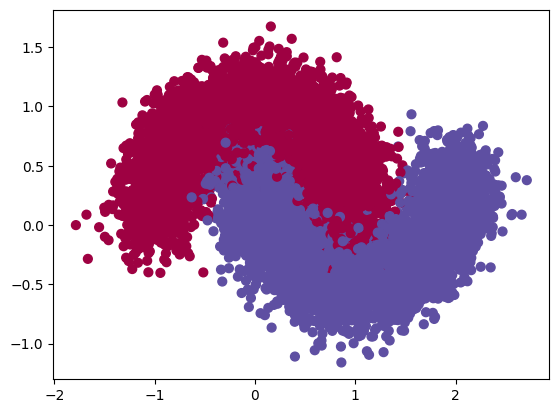

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

train_X, train_Y = sklearn.datasets.make_moons(n_samples=10000, noise=.2) #300 #0.2 Con make moons haces esta forma
test_X, test_Y = sklearn.datasets.make_moons(n_samples=1000, noise=.2)
# Visualize the data
plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);


In [2]:
import keras
from keras import layers
from keras.optimizers import Adam

# Define the model
model = keras.Sequential([
    layers.Input(shape=(2,)),  # Input layer
    layers.Dense(5, activation='relu'),  
    layers.Dense(2, activation='relu'),   
    layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenar el modelo
batch_size = 10000 # si esto lo bajamos a 1000, el modelo tarda más. Tenemos 10000 casos y para cubrir todo el dataset tenemos que hacer 10 iteraciones. Si ponemos batch_size=100, entonces tenemos que hacer 100 iteraciones para cubrir todo el dataset. Cuanto más pequeño es el batch_size, más iteraciones tenemos que hacer para cubrir todo el dataset, y por lo tanto, más tiempo tarda el modelo en entrenar.
epochs = 300 # y en caso de los epochs, si tenemos ahora 1000 para 10000 casos, entonces el modelo tarda 300 iteraciones para entrenar. Si ponemos epochs=1000, entonces el modelo tarda 1000 iteraciones para entrenar. Cuanto más grande es el epochs, más iteraciones tenemos que hacer para entrenar el modelo, y por lo tanto, más tiempo tarda el modelo en entrenar. Podríamos bajarlo a 30 y el modelo tarda mucho menos, pero el modelo no aprende tanto. Cuanto más pequeño es el epochs, menos iteraciones tenemos que hacer para entrenar el modelo, y por lo tanto, menos tiempo tarda el modelo en entrenar, pero el modelo no aprende tanto.
historia = model.fit(
    train_X, train_Y,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(test_X, test_Y))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.7332 - val_accuracy: 0.4830 - val_loss: 0.7216
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4917 - loss: 0.7230 - val_accuracy: 0.5060 - val_loss: 0.7129
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5218 - loss: 0.7142 - val_accuracy: 0.5580 - val_loss: 0.7053
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5621 - loss: 0.7065 - val_accuracy: 0.6030 - val_loss: 0.6989
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6049 - loss: 0.7000 - val_accuracy: 0.6290 - val_loss: 0.6936
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6383 - loss: 0.6947 - val_accuracy: 0.6670 - val_loss: 0.6893
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6633 - loss: 0.6902 - val_accuracy: 0.6850 - val_loss: 0.6857
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6812 - loss: 0.6865 - val_accuracy: 0.6970 - val_loss

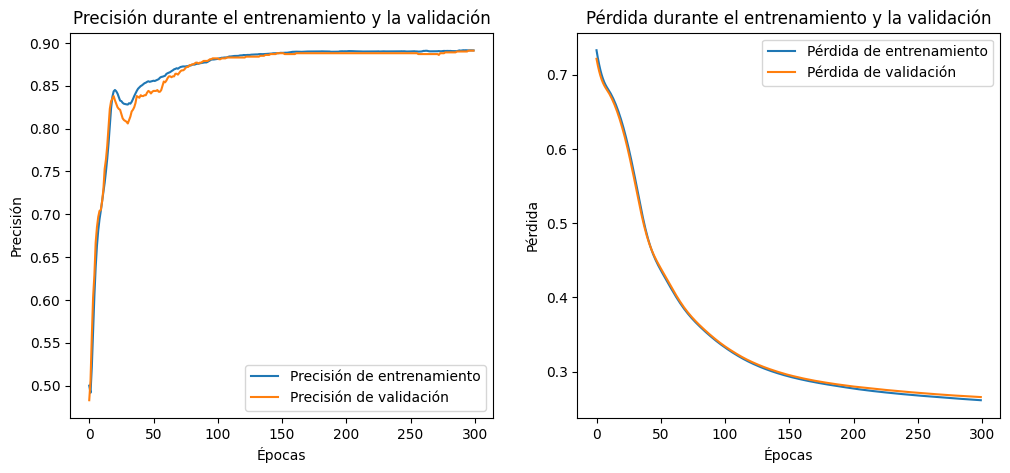

In [4]:
# Graficar las curvas de entrenamiento
plt.figure(figsize=(12, 5))

# Gráfica de la precisión
plt.subplot(1, 2, 1)
plt.plot(historia.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(historia.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión durante el entrenamiento y la validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfica de la pérdida
plt.subplot(1, 2, 2)
plt.plot(historia.history['loss'], label='Pérdida de entrenamiento')
plt.plot(historia.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento y la validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()